In [ ]:
import marimo as mo

# RSNA Pneumonia → Gemma-4-E4B JSON

Notebook **marimo** révisé pour :
- analyser un dossier Kaggle du dataset **RSNA Pneumonia Processed Dataset** ;
- détecter automatiquement la structure utile (`patientId`, `Target`, `x`, `y`, `width`, `height`) ;
- agréger les annotations par image ;
- générer un dataset multimodal conversationnel pour **Gemma-4-E4B-it** ;
- entraîner un adaptateur **LoRA** avec Unsloth ;
- tester une inférence sur une radiographie ;
- choisir entre une cible **JSON minimale** (`predicted_class`) et un **JSON complet**.

## Contrainte marimo respectée
Chaque nom global est défini une seule fois pour limiter les problèmes de réactivité et de redéfinition.

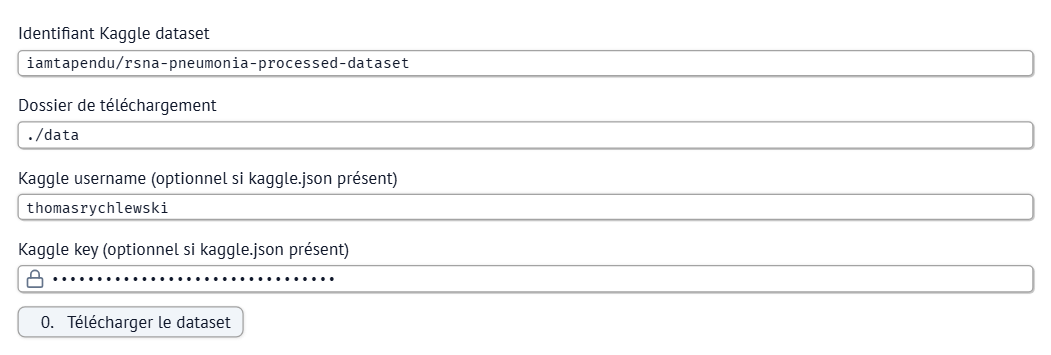

In [ ]:
ui_kaggle_dataset = mo.ui.text(
    label="Identifiant Kaggle dataset",
    value="iamtapendu/rsna-pneumonia-processed-dataset",
    full_width=True,
)

ui_kaggle_download_root = mo.ui.text(
    label="Dossier de téléchargement",
    value="./data",
    full_width=True,
)

ui_kaggle_username = mo.ui.text(
    label="Kaggle username (optionnel si kaggle.json présent)",
    value="",
    full_width=True,
)

ui_kaggle_key = mo.ui.text(
    label="Kaggle key (optionnel si kaggle.json présent)",
    value="",
    kind="password",
    full_width=True,
)

ui_download_dataset = mo.ui.run_button(label="0. Télécharger le dataset")
mo.vstack([
    ui_kaggle_dataset,
    ui_kaggle_download_root,
    ui_kaggle_username,
    ui_kaggle_key,
    ui_download_dataset,
])

In [ ]:
kaggle_download_bundle = None

if ui_download_dataset.value:
    download_root_path = Path(ui_kaggle_download_root.value).expanduser().resolve()
    dataset_slug = ui_kaggle_dataset.value.strip()
    dataset_name = dataset_slug.split("/")[-1]
    dataset_extract_path = download_root_path / dataset_name
    download_root_path.mkdir(parents=True, exist_ok=True)
    dataset_extract_path.mkdir(parents=True, exist_ok=True)

    kaggle_config_dir = Path.home()
    kaggle_config_path = kaggle_config_dir / "kaggle.json"
    kaggle_username_value = ui_kaggle_username.value.strip()
    kaggle_key_value = ui_kaggle_key.value.strip()

    if kaggle_username_value and kaggle_key_value:
        kaggle_config_dir.mkdir(parents=True, exist_ok=True)
        kaggle_config_path.write_text(
            json.dumps({"username": kaggle_username_value, "key": kaggle_key_value}, ensure_ascii=False),
            encoding="utf-8",
        )
        os.chmod(kaggle_config_path, 0o600)
        os.environ["KAGGLE_USERNAME"] = kaggle_username_value
        os.environ["KAGGLE_KEY"] = kaggle_key_value

    try:
        from kaggle.api.kaggle_api_extended import KaggleApi

        kaggle_api = KaggleApi()
        kaggle_api.authenticate()
        kaggle_api.dataset_download_files(
            dataset_slug,
            path=str(dataset_extract_path),
            unzip=True,
            quiet=False,
        )

        downloaded_files = sorted([str(item) for item in dataset_extract_path.rglob("*") if item.is_file()])
        kaggle_download_bundle = {
            "status": "ok",
            "dataset_slug": dataset_slug,
            "download_root": str(download_root_path),
            "dataset_path": str(dataset_extract_path),
            "num_files": len(downloaded_files),
            "sample_files": downloaded_files[:20],
            "kaggle_config_used": str(kaggle_config_path) if kaggle_config_path.exists() else None,
        }
    except Exception as kaggle_error:
        kaggle_download_bundle = {
            "status": "error",
            "dataset_slug": dataset_slug,
            "download_root": str(download_root_path),
            "dataset_path": str(dataset_extract_path),
            "message": str(kaggle_error),
            "hint": "Vérifie kaggle.json ou KAGGLE_USERNAME/KAGGLE_KEY, ainsi que l'installation du package kaggle.",
        }

Dataset URL: https://www.kaggle.com/datasets/iamtapendu/rsna-pneumonia-processed-dataset


100%|██████████| 10.9G/10.9G [01:16<00:00, 154MB/s]


In [ ]:
if kaggle_download_bundle is None:
    mo.md("En attente du téléchargement Kaggle.")
elif kaggle_download_bundle["status"] == "error":
    mo.md(f"**Erreur téléchargement** : {kaggle_download_bundle['message']}")
    kaggle_download_bundle
else:
    mo.md("## Résultat téléchargement Kaggle")
    kaggle_download_bundle

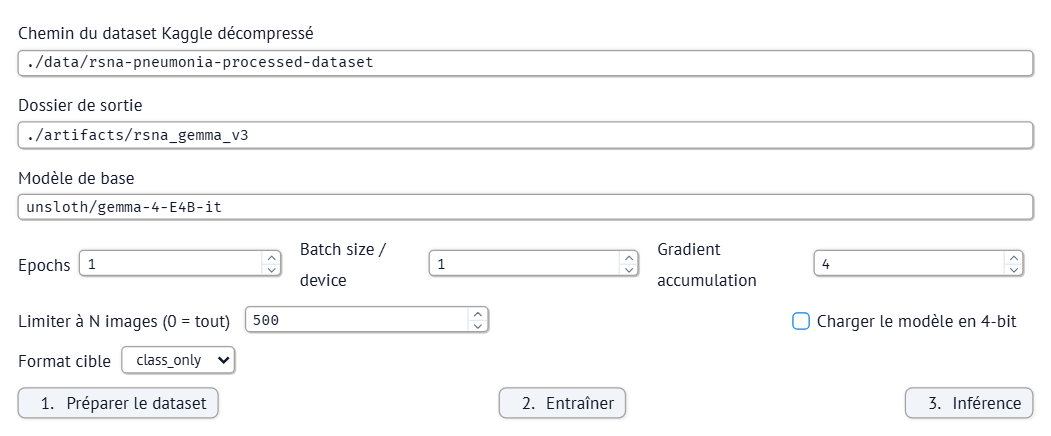

In [ ]:
ui_dataset_root = mo.ui.text(
    label="Chemin du dataset Kaggle décompressé",
    value="./data/rsna-pneumonia-processed-dataset",
    full_width=True,
)

ui_output_root = mo.ui.text(
    label="Dossier de sortie",
    value="./artifacts/rsna_gemma_v3",
    full_width=True,
)

ui_model_name = mo.ui.text(
    label="Modèle de base",
    value="unsloth/gemma-4-E4B-it",
    full_width=True,
)

ui_epochs = mo.ui.number(label="Epochs", value=1, start=1, stop=10, step=1)
ui_batch_size = mo.ui.number(label="Batch size / device", value=1, start=1, stop=16, step=1)
ui_grad_acc = mo.ui.number(label="Gradient accumulation", value=4, start=1, stop=64, step=1)
ui_image_limit = mo.ui.number(label="Limiter à N images (0 = tout)", value=500, start=0, stop=1000000, step=100)
ui_use_4bit = mo.ui.checkbox(label="Charger le modèle en 4-bit", value=False)

ui_output_mode = mo.ui.dropdown(
    options={
        "class_only": "JSON minimal (predicted_class)",
        "full_json": "JSON complet",
    },
    value="class_only",
    label="Format cible",
)

ui_prepare = mo.ui.run_button(label="1. Préparer le dataset")
ui_train = mo.ui.run_button(label="2. Entraîner")
ui_infer = mo.ui.run_button(label="3. Inférence")

mo.vstack([
    ui_dataset_root,
    ui_output_root,
    ui_model_name,
    mo.hstack([ui_epochs, ui_batch_size, ui_grad_acc]),
    mo.hstack([ui_image_limit, ui_use_4bit]),
    ui_output_mode,
    mo.hstack([ui_prepare, ui_train, ui_infer]),
])

In [ ]:
import json
import math
import os
import random
import re
from collections import defaultdict
from pathlib import Path

import pandas as pd
from PIL import Image

import torch
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHINDUCTOR_DISABLE"] = "1"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0625 07:58:36.871000 217 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0625 07:58:36.942000 217 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


<string>:1: FutureWarning: torch._dynamo.config.inline_inbuilt_nn_modules is deprecated and does not do anything, inline_inbuilt_nn_modules is always True. It will be removed in a future version of PyTorch.


## Installation

```bash
pip install -U marimo pandas pillow datasets transformers accelerate peft trl unsloth kaggle scikit-learn
```

Pour CUDA/PyTorch, installe une version de `torch` compatible avec ton environnement avant de lancer l'entraînement.

In [ ]:
def helper_find_files(root: Path):
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
    excluded_tokens = ["mask", "masks", "seg", "segmentation", "label"]
    all_images = []
    for p in root.rglob("*"):
        if p.suffix.lower() not in image_exts:
            continue
        lower_path = str(p).lower()
        if any(token in lower_path for token in excluded_tokens):
            continue
        all_images.append(p)
    all_images = sorted(all_images)
    all_csvs = sorted(root.rglob("*.csv"))
    return all_images, all_csvs

def helper_pick_label_csv(csv_paths):
    scored = []
    for csv_path in csv_paths:
        try:
            frame = pd.read_csv(csv_path)
        except Exception:
            continue
        cols = {str(c).lower() for c in frame.columns}
        score = 0
        if "patientid" in cols:
            score += 5
        if "target" in cols:
            score += 5
        if any(c in cols for c in ["x", "y", "width", "height"]):
            score += 3
        if "class" in cols:
            score += 2
        scored.append((score, csv_path, frame))
    scored.sort(key=lambda t: t[0], reverse=True)
    return scored[0] if scored else (None, None, None)

def helper_find_class_csv(csv_paths):
    for csv_path in csv_paths:
        try:
            frame = pd.read_csv(csv_path)
        except Exception:
            continue
        cols = {str(c).lower() for c in frame.columns}
        if "patientid" in cols and "class" in cols:
            return csv_path, frame
    return None, None

def helper_guess_image_map(image_paths):
    mapping = {}
    for imgpath in image_paths:
        stem = imgpath.stem.lower()
        lower_path = str(imgpath).lower()
        if stem not in mapping:
            mapping[stem] = imgpath
        else:
            current = str(mapping[stem]).lower()
            if "mask" in current and "mask" not in lower_path:
                mapping[stem] = imgpath
    return mapping

def helper_zone_from_bbox(bbox_row):
    try:
        x_val = float(bbox_row.get("x", math.nan))
        y_val = float(bbox_row.get("y", math.nan))
        w_val = float(bbox_row.get("width", math.nan))
        h_val = float(bbox_row.get("height", math.nan))
    except Exception:
        return "zone pulmonaire indéterminée"

    if any(math.isnan(v) for v in [x_val, y_val, w_val, h_val]):
        return "zone pulmonaire indéterminée"

    cx = x_val + (w_val / 2.0)
    cy = y_val + (h_val / 2.0)
    laterality = "droite" if cx >= 512 else "gauche"
    vertical = "basale" if cy >= 512 else "supérieure"
    return f"hémithorax {laterality}, prédominance {vertical}"

def helper_merge_bboxes(patient_rows):
    valid_boxes = []
    for row in patient_rows:
        try:
            row_target = int(float(row.get("Target", 0)))
        except Exception:
            row_target = 0
        if row_target != 1:
            continue
        has_any_box = any(str(row.get(k, "")).strip() not in ["", "nan", "None"] for k in ["x", "y", "width", "height"])
        if has_any_box:
            valid_boxes.append(row)
    return valid_boxes

def helper_build_json_target(patient_id, patient_rows, class_name=None):
    positive_rows = helper_merge_bboxes(patient_rows)
    positive_flag = any(str(r.get("Target", "0")) in ["1", "1.0"] for r in patient_rows)

    if not positive_flag:
        return {
            "patient_id": patient_id,
            "predicted_class": "Normal",
            "visual_evidence": "Aucune opacité focale évidente détectée",
            "justification": "Absence d'anomalie radiographique évidente en faveur d'une pneumonie sur cette image.",
            "warning": "Résultat à confirmer par un radiologue.",
        }

    if positive_rows:
        zones = [helper_zone_from_bbox(row) for row in positive_rows]
        unique_zones = sorted(set(zones))
        joined_zone = "; ".join(unique_zones[:3])
        return {
            "patient_id": patient_id,
            "predicted_class": "Pneumonie",
            "visual_evidence": f"Opacité pulmonaire localisée : {joined_zone}",
            "justification": "Présence d'opacités focales compatibles avec une pneumonie.",
            "warning": "Résultat à confirmer par un radiologue.",
        }

    class_hint = (class_name or "").lower()
    if "not normal" in class_hint or "opacity" in class_hint:
        visual_hint = "Anomalie pulmonaire visible sans localisation précise conservée"
    else:
        visual_hint = "Opacités pulmonaires compatibles avec une pneumonie"

    return {
        "patient_id": patient_id,
        "predicted_class": "Pneumonie",
        "visual_evidence": visual_hint,
        "justification": "Anomalies radiographiques compatibles avec une pneumonie.",
        "warning": "Résultat à confirmer par un radiologue.",
    }

def helper_make_messages(image_path: str, target_json: dict, output_mode: str):
    if output_mode == "class_only":
        prompt_text = (
            "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
            "sans markdown, sans texte avant ou après, avec exactement la clé predicted_class."
        )
        assistant_payload = {
            "predicted_class": target_json["predicted_class"],
        }
    else:
        prompt_text = (
            "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
            "sans markdown, sans texte avant ou après, avec exactement les clés predicted_class, "
            "visual_evidence, justification, warning."
        )
        assistant_payload = {
            "predicted_class": target_json["predicted_class"],
            "visual_evidence": target_json["visual_evidence"],
            "justification": target_json["justification"],
            "warning": target_json["warning"],
        }

    assistant_text = json.dumps(assistant_payload, ensure_ascii=False, separators=(",", ":"))

    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": prompt_text},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": assistant_text}
            ],
        },
    ]

def helper_train_val_split(items, seed=42, ratio=0.9):
    items_copy = list(items)
    rng = random.Random(seed)
    rng.shuffle(items_copy)
    cut = int(len(items_copy) * ratio)
    return items_copy[:cut], items_copy[cut:]

def helper_candidate_image_keys(patient_id: str):
    normalized = str(patient_id).strip().lower()
    return {
        normalized,
        normalized.replace(".dcm", ""),
        normalized.replace(".png", ""),
        normalized.replace(".jpg", ""),
        normalized.replace(".jpeg", ""),
    }

In [ ]:
prepared_bundle = None

if ui_prepare.value:
    dataset_root_path = Path(ui_dataset_root.value).expanduser().resolve()
    output_root_path = Path(ui_output_root.value).expanduser().resolve()
    output_root_path.mkdir(parents=True, exist_ok=True)

    found_images, found_csvs = helper_find_files(dataset_root_path)
    label_score, label_csv_path, label_frame = helper_pick_label_csv(found_csvs)
    class_csv_path, class_frame = helper_find_class_csv(found_csvs)
    image_map = helper_guess_image_map(found_images)

    if not found_images:
        prepared_bundle = {
            "status": "error",
            "message": f"Aucune image détectée dans {dataset_root_path}",
        }
    elif label_frame is None:
        prepared_bundle = {
            "status": "error",
            "message": "Aucun CSV de labels plausible détecté. Vérifie la structure du dataset Kaggle.",
            "csv_candidates": [str(p) for p in found_csvs],
        }
    else:
        label_frame_local = label_frame.copy()
        label_columns_lower = {str(col).lower(): col for col in label_frame_local.columns}
        patient_col = label_columns_lower.get("patientid") or next(iter(label_frame_local.columns))
        target_col = label_columns_lower.get("target")
        x_col = label_columns_lower.get("x")
        y_col = label_columns_lower.get("y")
        width_col = label_columns_lower.get("width")
        height_col = label_columns_lower.get("height")

        normalized_label_frame = label_frame_local.rename(columns={
            patient_col: "patientId",
            **({target_col: "Target"} if target_col else {}),
            **({x_col: "x"} if x_col else {}),
            **({y_col: "y"} if y_col else {}),
            **({width_col: "width"} if width_col else {}),
            **({height_col: "height"} if height_col else {}),
        })

        class_lookup = {}
        if class_frame is not None:
            class_frame_local = class_frame.copy()
            class_cols = {str(col).lower(): col for col in class_frame_local.columns}
            if "patientid" in class_cols and "class" in class_cols:
                class_lookup = dict(
                    zip(
                        class_frame_local[class_cols["patientid"]].astype(str).str.lower(),
                        class_frame_local[class_cols["class"]].astype(str),
                    )
                )

        rows_by_patient = defaultdict(list)
        for row_dict in normalized_label_frame.to_dict(orient="records"):
            patient_key = str(row_dict.get("patientId", "")).strip().lower()
            if patient_key:
                rows_by_patient[patient_key].append(row_dict)

        selected_patient_ids = sorted(rows_by_patient.keys())
        if int(ui_image_limit.value) > 0:
            selected_patient_ids = selected_patient_ids[: int(ui_image_limit.value)]

        prepared_records = []
        unmatched_patient_ids = []
        for patient_id in selected_patient_ids:
            resolved_image_path = None
            for candidate_key in helper_candidate_image_keys(patient_id):
                if candidate_key in image_map:
                    resolved_image_path = image_map[candidate_key]
                    break
            if resolved_image_path is None:
                unmatched_patient_ids.append(patient_id)
                continue

            target_struct = helper_build_json_target(
                patient_id=patient_id,
                patient_rows=rows_by_patient[patient_id],
                class_name=class_lookup.get(patient_id),
            )

            prepared_records.append(
                {
                    "patient_id": patient_id,
                    "image": str(resolved_image_path),
                    "target": target_struct,
                    "messages": helper_make_messages(
                        str(resolved_image_path),
                        target_struct,
                        ui_output_mode.value,
                    ),
                }
            )

        train_records, val_records = helper_train_val_split(prepared_records, seed=42, ratio=0.9)

        train_jsonl_path = output_root_path / "train.jsonl"
        val_jsonl_path = output_root_path / "val.jsonl"
        preview_json_path = output_root_path / "preview_records.json"
        analysis_json_path = output_root_path / "dataset_analysis.json"

        with train_jsonl_path.open("w", encoding="utf-8") as file_train:
            for item in train_records:
                file_train.write(json.dumps(item, ensure_ascii=False) + "\n")

        with val_jsonl_path.open("w", encoding="utf-8") as file_val:
            for item in val_records:
                file_val.write(json.dumps(item, ensure_ascii=False) + "\n")

        with preview_json_path.open("w", encoding="utf-8") as file_preview:
            json.dump(prepared_records[:5], file_preview, ensure_ascii=False, indent=2)

        analysis_payload = {
            "dataset_root": str(dataset_root_path),
            "output_root": str(output_root_path),
            "num_images_detected": len(found_images),
            "num_csv_detected": len(found_csvs),
            "label_csv": str(label_csv_path) if label_csv_path else None,
            "label_csv_score": label_score,
            "class_csv": str(class_csv_path) if class_csv_path else None,
            "label_columns": list(label_frame.columns),
            "num_patients_in_labels": len(rows_by_patient),
            "num_records_prepared": len(prepared_records),
            "num_records_train": len(train_records),
            "num_records_val": len(val_records),
            "num_unmatched_patients": len(unmatched_patient_ids),
            "sample_unmatched_patients": unmatched_patient_ids[:20],
            "train_jsonl": str(train_jsonl_path),
            "val_jsonl": str(val_jsonl_path),
            "preview_json": str(preview_json_path),
            "output_mode": ui_output_mode.value,
        }

        with analysis_json_path.open("w", encoding="utf-8") as file_analysis:
            json.dump(analysis_payload, file_analysis, ensure_ascii=False, indent=2)

        prepared_bundle = {
            "status": "ok",
            "analysis": analysis_payload,
            "analysis_json_path": str(analysis_json_path),
            "train_jsonl_path": str(train_jsonl_path),
            "val_jsonl_path": str(val_jsonl_path),
            "preview_json_path": str(preview_json_path),
            "output_mode": ui_output_mode.value,
        }

In [ ]:
mo_preparation_output = None

if prepared_bundle is None:
    mo_preparation_output = mo.md("En attente de la préparation du dataset.")
elif prepared_bundle["status"] == "error":
    mo_preparation_output = mo.md(f"**Erreur préparation** : {prepared_bundle['message']}")
    prepared_bundle
else:
    mo_preparation_output = mo.md("## Analyse du dataset et fichiers générés")
    prepared_bundle["analysis"]

mo_preparation_output

<span class="markdown prose dark:prose-invert contents"><h2 id="analyse-du-dataset-et-fichiers-generes">Analyse du dataset et fichiers générés</h2></span>

Generating train split: 450 examples [00:00, 50885.28 examples/s]
Generating validation split: 50 examples [00:00, 18223.43 examples/s]


==((====))==  Unsloth 2026.6.7: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.12.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights: 100%|██████████| 2130/2130 [00:09<00:00, 223.72it/s] 


Unsloth: Model does not have a default image size - using 512


[accelerate.utils.other|WARNING][RANK 0] Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 1 | Total steps = 113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 36,700,160 of 8,032,856,608 (0.46% trained)
Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate

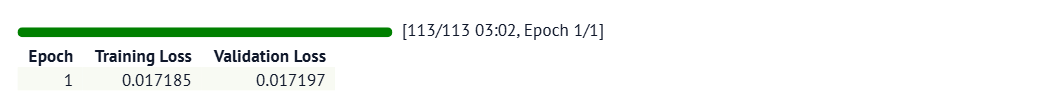

In [ ]:
training_bundle = None

if ui_train.value:
    if prepared_bundle is None or prepared_bundle["status"] != "ok":
        training_bundle = {
            "status": "error",
            "message": "Prépare d'abord le dataset avant l'entraînement.",
        }
    else:
        train_data_path = prepared_bundle["train_jsonl_path"]
        val_data_path = prepared_bundle["val_jsonl_path"]
        trained_model_dir = Path(ui_output_root.value).expanduser().resolve() / "model_lora"
        trained_model_dir.mkdir(parents=True, exist_ok=True)

        hf_dataset = load_dataset(
            "json",
            data_files={
                "train": train_data_path,
                "validation": val_data_path,
            },
        )

        base_model, base_tokenizer = FastVisionModel.from_pretrained(
            model_name=ui_model_name.value,
            load_in_4bit=bool(ui_use_4bit.value),
            use_gradient_checkpointing=False,
        )

        peft_model = FastVisionModel.get_peft_model(
            base_model,
            finetune_vision_layers=False,
            finetune_language_layers=True,
            finetune_attention_modules=True,
            finetune_mlp_modules=True,
            r=16,
            lora_alpha=16,
            lora_dropout=0,
            bias="none",
            random_state=3407,
        )

        trainer_config = SFTConfig(
            output_dir=str(trained_model_dir),
            per_device_train_batch_size=int(ui_batch_size.value),
            gradient_accumulation_steps=int(ui_grad_acc.value),
            num_train_epochs=int(ui_epochs.value),
            learning_rate=2e-4,
            logging_steps=5,
            save_strategy="epoch",
            eval_strategy="epoch",
            bf16=True,
            remove_unused_columns=False,
            dataset_text_field="",
            report_to="none",
        )

        sft_trainer = SFTTrainer(
            model=peft_model,
            tokenizer=base_tokenizer,
            train_dataset=hf_dataset["train"],
            eval_dataset=hf_dataset["validation"],
            data_collator=UnslothVisionDataCollator(peft_model, base_tokenizer),
            args=trainer_config,
        )

        training_stats = sft_trainer.train()
        sft_trainer.save_model(str(trained_model_dir))
        base_tokenizer.save_pretrained(str(trained_model_dir))

        metrics_file_path = trained_model_dir / "train_metrics.json"
        metrics_file_path.write_text(
            json.dumps(training_stats.metrics, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

        training_bundle = {
            "status": "ok",
            "model_dir": str(trained_model_dir),
            "metrics_path": str(metrics_file_path),
            "metrics": training_stats.metrics,
        }

In [ ]:
training_output = None

if training_bundle is None:
    training_output = mo.md("En attente de l'entraînement.")
elif training_bundle["status"] == "error":
    training_output = mo.md(f"**Erreur entraînement** : {training_bundle['message']}")
else:
    training_output = mo.md("## Résultat de l'entraînement")
    training_bundle

training_output

<span class="markdown prose dark:prose-invert contents"><h2 id="resultat-de-lentrainement">Résultat de l'entraînement</h2></span>

In [ ]:
def extract_json_payload(text: str):
    text = str(text or "").strip()
    if not text:
        return None, "empty_output"

    candidates = [text]

    fence_matches = re.findall(
        r"```json\s*(.*?)\s*```",
        text,
        flags=re.DOTALL | re.IGNORECASE,
    )
    fence_matches += re.findall(
        r"```\s*(.*?)\s*```",
        text,
        flags=re.DOTALL,
    )
    for match in fence_matches:
        match = match.strip()
        if match:
            candidates.append(match)

    brace_matches = re.findall(r"\{.*?\}", text, flags=re.DOTALL)
    for match in brace_matches:
        match = match.strip()
        if match:
            candidates.append(match)

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        if candidate not in seen:
            seen.add(candidate)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        try:
            parsed = json.loads(candidate)
            if isinstance(parsed, dict):
                return parsed, "ok"
        except Exception:
            continue

    if "```" in text:
        return None, "markdown_or_truncated_json"
    if "{" in text and "}" not in text:
        return None, "truncated_json"
    if "{" in text and "}" in text:
        return None, "invalid_json_object"
    return None, "no_json_found"

def extract_json_pred_class(text: str) -> str:
    payload, _ = extract_json_payload(text)
    if isinstance(payload, dict):
        return str(payload.get("predicted_class", "")).strip()
    return ""

In [ ]:
eval_output = None
eval_bundle = None

max_eval_examples = 40
count_invalid_format_as_error = True

if prepared_bundle is None:
    eval_bundle = {
        "status": "error",
        "message": "Prépare d'abord le dataset avant de lancer l'évaluation.",
    }
elif prepared_bundle["status"] != "ok":
    eval_bundle = {
        "status": "error",
        "message": "La préparation du dataset a échoué.",
    }
elif training_bundle is None:
    eval_bundle = {
        "status": "error",
        "message": "Entraîne d'abord le modèle avant de lancer l'évaluation.",
    }
elif training_bundle["status"] != "ok":
    eval_bundle = {
        "status": "error",
        "message": "L'entraînement du modèle a échoué.",
    }
else:
    val_path = Path(prepared_bundle["val_jsonl_path"])
    records = [
        json.loads(line)
        for line in val_path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    records = records[:max_eval_examples]

    y_true = []
    y_pred = []
    raw_predictions = []

    model_dir = training_bundle["model_dir"]
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=model_dir,
        load_in_4bit=False,
    )
    FastVisionModel.for_inference(model)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    _output_mode = prepared_bundle.get("output_mode", "class_only")

    if _output_mode == "class_only":
        prompt = (
            "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
            "sans markdown, sans texte avant ou après, avec exactement la clé predicted_class."
        )
        max_new_tokens = 24
    else:
        prompt = (
            "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
            "sans markdown, sans texte avant ou après, avec exactement les clés predicted_class, "
            "visual_evidence, justification, warning."
        )
        max_new_tokens = 128

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    input_text_metrics = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    with torch.inference_mode():
        for rec in records:
            img_path = rec["image"]
            tgt_class = str(rec["target"]["predicted_class"]).strip()

            try:
                image_metrics = Image.open(img_path).convert("RGB")

                inputs = tokenizer(
                    image_metrics,
                    input_text_metrics,
                    add_special_tokens=False,
                    return_tensors="pt",
                ).to(device)

                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    use_cache=True,
                )

                decoded = tokenizer.batch_decode(
                    outputs,
                    skip_special_tokens=True,
                )[0]

                payload, parse_status = extract_json_payload(decoded)
                pred_class = ""
                if isinstance(payload, dict):
                    pred_class = str(payload.get("predicted_class", "")).strip()

            except Exception as inference_error:
                decoded = f"__ERROR__ {str(inference_error)}"
                payload = None
                parse_status = "inference_error"
                pred_class = ""

            y_true.append(tgt_class)
            y_pred.append(pred_class)

            raw_predictions.append(
                {
                    "image": img_path,
                    "target_class": tgt_class,
                    "predicted_class": pred_class,
                    "raw_output": decoded,
                    "parsed_payload": payload,
                    "parse_status": parse_status,
                }
            )

    effective_y_pred = [
        pred if pred else "__INVALID__"
        for pred in y_pred
    ] if count_invalid_format_as_error else y_pred

    acc = accuracy_score(y_true, effective_y_pred)

    y_true_bin = [1 if y == "Pneumonie" else 0 for y in y_true]
    y_pred_bin = [1 if y == "Pneumonie" else 0 for y in effective_y_pred]

    prec_bin, rec_bin, f1_bin, _ = precision_recall_fscore_support(
        y_true_bin,
        y_pred_bin,
        average="binary",
        zero_division=0,
    )

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        effective_y_pred,
        average="macro",
        zero_division=0,
    )

    num_json_failures = sum(1 for pred in y_pred if pred == "")

    parse_status_counts = {}
    for item_pred in raw_predictions:
        key = item_pred["parse_status"]
        parse_status_counts[key] = parse_status_counts.get(key, 0) + 1

    eval_bundle = {
        "status": "ok",
        "num_records": len(records),
        "val_path": str(val_path),
        "output_mode": _output_mode,
        "metrics": {
            "accuracy": float(acc),
            "pneumonie_precision": float(prec_bin),
            "pneumonie_recall": float(rec_bin),
            "pneumonie_f1": float(f1_bin),
            "macro_precision": float(prec_macro),
            "macro_recall": float(rec_macro),
            "macro_f1": float(f1_macro),
            "json_parse_failures": int(num_json_failures),
        },
        "parse_status_counts": parse_status_counts,
        "sample_predictions": raw_predictions[:5],
        "unique_true_labels": sorted(set(y_true)),
        "unique_pred_labels": sorted(set(effective_y_pred)),
    }

if eval_bundle["status"] == "error":
    eval_output = mo.md(f"**Erreur évaluation** : {eval_bundle['message']}")
else:
    metrics = eval_bundle["metrics"]
    eval_output = mo.md(
        f"""
## Résultat évaluation

- Mode cible : `{eval_bundle['output_mode']}`
- Nombre d'exemples évalués : `{eval_bundle['num_records']}`
- Fichier validation : `{eval_bundle['val_path']}`
- Accuracy : `{metrics['accuracy']:.4f}`
- Precision (Pneumonie) : `{metrics['pneumonie_precision']:.4f}`
- Recall (Pneumonie) : `{metrics['pneumonie_recall']:.4f}`
- F1 (Pneumonie) : `{metrics['pneumonie_f1']:.4f}`
- Macro F1 : `{metrics['macro_f1']:.4f}`
- JSON non parsables : `{metrics['json_parse_failures']}`
- Statuts de parsing : `{eval_bundle['parse_status_counts']}`
- Labels vrais : `{eval_bundle['unique_true_labels']}`
- Labels prédits : `{eval_bundle['unique_pred_labels']}`
"""
    )

eval_output

==((====))==  Unsloth 2026.6.7: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.12.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights: 100%|██████████| 2130/2130 [00:09<00:00, 222.79it/s] 


<span class="markdown prose dark:prose-invert contents"><h2 id="resultat-evaluation">Résultat évaluation</h2>
<ul>
<li>Mode cible : <code>JSON minimal (predicted_class)</code></li>
<li>Nombre d'exemples évalués : <code>40</code></li>
<li>Fichier validation : <code>/marimo/artifacts/rsna_gemma_v3/val.jsonl</code></li>
<li>Accuracy : <code>0.7750</code></li>
<li>Precision (Pneumonie) : <code>0.8182</code></li>
<li>Recall (Pneumonie) : <code>0.5625</code></li>
<li>F1 (Pneumonie) : <code>0.6667</code></li>
<li>Macro F1 : <code>0.7484</code></li>
<li>JSON non parsables : <code>0</code></li>
<li>Statuts de parsing : <code>{'ok': 40}</code></li>
<li>Labels vrais : <code>['Normal', 'Pneumonie']</code></li>
<li>Labels prédits : <code>['Normal', 'Pneumonie']</code></li>
</ul></span>

In [ ]:
if eval_bundle is not None and eval_bundle.get("status") == "ok":
    for i, item_eval in enumerate(eval_bundle["sample_predictions"][:5]):
        print("---- EXEMPLE", i, "----")
        print("parse_status:", item_eval["parse_status"])
        print("target_class:", item_eval["target_class"])
        print("predicted_class:", item_eval["predicted_class"])
        print(item_eval["raw_output"])
        print()

---- EXEMPLE 0 ----
parse_status: ok
target_class: Normal
predicted_class: Normal
user
Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, sans markdown, sans texte avant ou après, avec exactement les clés predicted_class, visual_evidence, justification, warning.
model
{"predicted_class":"Normal","visual_evidence":"Aucune opacité focale évidente détectée","justification":"Absence d'anomalie radiographique évidente en faveur d'une pneumonie sur cette image.","warning":"Résultat à confirmer par un radiologue."}

---- EXEMPLE 1 ----
parse_status: ok
target_class: Normal
predicted_class: Normal
user
Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, sans markdown, sans texte avant ou après, avec exactement les clés predicted_class, visual_evidence, justification, warning.
model
{"predicted_class":"Normal","visual_evidence":"Aucune opacité focale évidente détectée","justification":"Absence d'anomalie 

In [ ]:
inference_bundle = None

if ui_infer.value:
    if prepared_bundle is None or prepared_bundle["status"] != "ok":
        inference_bundle = {
            "status": "error",
            "message": "Prépare le dataset avant de lancer une inférence.",
        }
    else:
        preview_records_path = Path(prepared_bundle["preview_json_path"])
        preview_records = json.loads(preview_records_path.read_text(encoding="utf-8"))
        sample_record = preview_records[0]
        sample_image_path = sample_record["image"]

        final_model_ref = (
            training_bundle["model_dir"]
            if training_bundle is not None and training_bundle.get("status") == "ok"
            else ui_model_name.value
        )

        infer_model, infer_tokenizer = FastVisionModel.from_pretrained(
            model_name=final_model_ref,
            load_in_4bit=False,
        )
        FastVisionModel.for_inference(infer_model)

        image = Image.open(sample_image_path).convert("RGB")
        output_mode = prepared_bundle.get("output_mode", "class_only")

        if output_mode == "class_only":
            inference_prompt = (
                "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
                "sans markdown, sans texte avant ou après, avec exactement la clé predicted_class."
            )
            inference_max_tokens = 24
        else:
            inference_prompt = (
                "Analyse cette radiographie thoracique et retourne uniquement un JSON valide sur une seule ligne, "
                "sans markdown, sans texte avant ou après, avec exactement les clés predicted_class, "
                "visual_evidence, justification, warning."
            )
            inference_max_tokens = 128

        chat_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": inference_prompt},
                ],
            }
        ]

        input_text = infer_tokenizer.apply_chat_template(
            chat_messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        tokenized_inputs = infer_tokenizer(
            image,
            input_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda" if torch.cuda.is_available() else "cpu")

        generated_outputs = infer_model.generate(
            **tokenized_inputs,
            max_new_tokens=inference_max_tokens,
            do_sample=False,
            use_cache=True,
        )

        decoded_output = infer_tokenizer.batch_decode(
            generated_outputs,
            skip_special_tokens=True,
        )[0]

        inference_output_path = Path(ui_output_root.value).expanduser().resolve() / "sample_inference.txt"
        inference_output_path.write_text(decoded_output, encoding="utf-8")

        inference_bundle = {
            "status": "ok",
            "sample_image_path": sample_image_path,
            "raw_output": decoded_output,
            "output_file": str(inference_output_path),
            "output_mode": output_mode,
        }

In [ ]:
mo_inference_output = None

if inference_bundle is None:
    mo_inference_output = mo.md("En attente d'une inférence.")
elif inference_bundle["status"] == "error":
    mo_inference_output = mo.md(f"**Erreur inférence** : {inference_bundle['message']}")
else:
    sample_image = Image.open(inference_bundle["sample_image_path"])
    mo_inference_output = mo.vstack([
        mo.md(f"## Image de test\n`{inference_bundle['sample_image_path']}`"),
        sample_image,
        mo.md(f"## Sortie brute du modèle ({inference_bundle['output_mode']})"),
        mo.md(f"```\n{inference_bundle['raw_output']}\n```"),
    ])

mo_inference_output

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">En attente d'une inférence.</span></span>

## Notes de conception

- Le notebook supprime `confidence` de la cible d'entraînement, car RSNA ne fournit pas une probabilité clinique de vérité terrain.
- Le mode `class_only` est recommandé pour stabiliser d'abord le format JSON.
- Les phrases de `visual_evidence` et `justification` restent prudentes, car RSNA est d'abord un dataset de détection/classification.
- Le parsing distingue `ok`, `truncated_json`, `invalid_json_object`, `markdown_or_truncated_json`, `no_json_found` et `inference_error`.
- L'évaluation pénalise les sorties invalides comme erreurs de prédiction si `count_invalid_format_as_error=True`.